# HW2: FashionMNIST классификация (PyTorch Lightning)

Цель: построить воспроизводимый классификатор FashionMNIST с Lightning, метриками F1/ROC AUC и логированием в TensorBoard.



In [4]:
#!pip install torch torchvision torchaudio pytorch-lightning torchmetrics tensorboard matplotlib  # если окружение пустое

In [5]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.classification import MulticlassF1Score, MulticlassAUROC


In [6]:
SEED = 42
pl.seed_everything(SEED, workers=True)

def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)

set_global_seed(SEED)

print('PyTorch version:', torch.__version__)
print('Lightning version:', pl.__version__)
print('Torchvision version:', torchvision.__version__)
print('Device:', 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')


Seed set to 42


PyTorch version: 2.9.1
Lightning version: 2.6.0
Torchvision version: 0.24.1
Device: mps


## Конфигурация и трансформации

In [7]:
@dataclass
class CFG:
    data_dir: Path = Path('data/fashionmnist')
    batch_size: int = 128
    num_workers: int = 0  # можно увеличить, если в ОС разрешено шарить память между воркерами
    val_size: int = 5_000
    lr: float = 1e-3
    weight_decay: float = 1e-4
    max_epochs: int = 20
    patience: int = 3
    gamma: float = 0.5  # для ReduceLROnPlateau
    min_lr: float = 1e-5
    label_map: list | None = None

mean, std = 0.2860, 0.3530  # усредненные значения FashionMNIST
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]),
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std]),
])


## Разведка данных

In [8]:
root = CFG.data_dir
train_raw = torchvision.datasets.FashionMNIST(root=root, train=True, download=True)
test_raw = torchvision.datasets.FashionMNIST(root=root, train=False, download=True)

label_map = train_raw.classes
CFG.label_map = label_map
print('Классы:', label_map)


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 359kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 998kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.81MB/s]

Классы: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


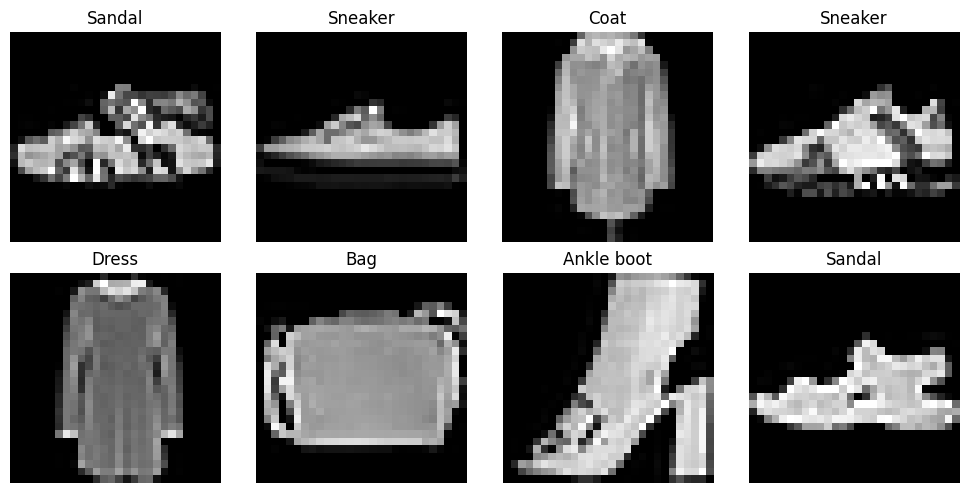

In [9]:
sample_ds = torchvision.datasets.FashionMNIST(root=root, train=True, transform=transforms.ToTensor())
sample_loader = DataLoader(sample_ds, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label_map[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()


## LightningDataModule

In [10]:
class FashionMNISTDataModule(LightningDataModule):
    def __init__(self, data_dir: Path, batch_size: int, num_workers: int, val_size: int, seed: int):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_size = val_size
        self.seed = seed

    def prepare_data(self):
        torchvision.datasets.FashionMNIST(root=self.data_dir, train=True, download=True)
        torchvision.datasets.FashionMNIST(root=self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        if stage == 'predict':
            return
        full_train = torchvision.datasets.FashionMNIST(
            root=self.data_dir, train=True, transform=train_transforms
        )
        train_len = len(full_train) - self.val_size
        val_len = self.val_size
        self.train_ds, self.val_ds = random_split(
            full_train, [train_len, val_len], generator=torch.Generator().manual_seed(self.seed)
        )
        self.test_ds = torchvision.datasets.FashionMNIST(
            root=self.data_dir, train=False, transform=test_transforms
        )

    def _make_loader(self, ds, shuffle=False):
        return DataLoader(
            ds,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            pin_memory=False,
        )

    def train_dataloader(self):
        return self._make_loader(self.train_ds, shuffle=True)

    def val_dataloader(self):
        return self._make_loader(self.val_ds, shuffle=False)

    def test_dataloader(self):
        return self._make_loader(self.test_ds, shuffle=False)


## Модель: CNN + LightningModule

In [11]:
class ConvNet(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class FashionMNISTModel(LightningModule):
    def __init__(self, lr: float, weight_decay: float, gamma: float, min_lr: float):
        super().__init__()
        self.save_hyperparameters()
        self.model = ConvNet(num_classes=10)
        self.loss_fn = nn.CrossEntropyLoss()
        self.val_f1 = MulticlassF1Score(num_classes=10, average='macro')
        self.test_f1 = MulticlassF1Score(num_classes=10, average='macro')
        self.val_auroc = MulticlassAUROC(num_classes=10)
        self.test_auroc = MulticlassAUROC(num_classes=10)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, stage: str):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        probs = torch.softmax(logits, dim=1)
        if stage == 'val':
            self.val_f1.update(preds, y)
            self.val_auroc.update(probs, y)
        elif stage == 'test':
            self.test_f1.update(preds, y)
            self.test_auroc.update(probs, y)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch, 'train')
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch, 'val')
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_auroc', self.val_auroc, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def test_step(self, batch, batch_idx):
        loss = self._shared_step(batch, 'test')
        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)
        self.log('test_auroc', self.test_auroc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=self.hparams.gamma, patience=2, min_lr=self.hparams.min_lr
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss', 'interval': 'epoch', 'frequency': 1},
        }


## Обучение

In [12]:
datamodule = FashionMNISTDataModule(
    data_dir=CFG.data_dir,
    batch_size=CFG.batch_size,
    num_workers=CFG.num_workers,
    val_size=CFG.val_size,
    seed=SEED,
)
model = FashionMNISTModel(
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
    gamma=CFG.gamma,
    min_lr=CFG.min_lr,
)

logger = TensorBoardLogger('lightning_logs', name='fashionmnist')
early_stop = EarlyStopping(monitor='val_loss', patience=CFG.patience, mode='min')
ckpt = ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1, filename='fashionmnist-{epoch:02d}-{val_loss:.3f}')
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(
    max_epochs=CFG.max_epochs,
    accelerator='auto',
    devices=1,
    logger=logger,
    callbacks=[early_stop, ckpt, lr_monitor],
    log_every_n_steps=50,
    deterministic=False,
)

trainer.fit(model, datamodule=datamodule)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name       | Type              | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model      | ConvNet           | 102 K  | train | 0    
1 | loss_fn    | CrossEntropyLoss  | 0      | train | 0    
2 | val_f1     | MulticlassF1Score | 0      | train | 0    
3 | test_f1    | MulticlassF1Score | 0      | train | 0    
4 | val_auroc  | MulticlassAUROC   | 0      | train | 0    
5 | test_auroc | MulticlassAUROC   | 0      | train | 0    
-----------------------------------------------------------------
102 K     Trainable params
0         Non-trainable params
102 K     Total params
0.408     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/savely/miniforge3/envs/dl_hw_2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/savely/miniforge3/envs/dl_hw_2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 430/430 [00:09<00:00, 43.25it/s, v_num=0, val_loss=0.370, val_f1=0.862, train_loss=0.318]


## Оценка на тесте

In [13]:
test_results = trainer.test(model, datamodule=datamodule, ckpt_path='best')
test_results


Restoring states from the checkpoint path at lightning_logs/fashionmnist/version_0/checkpoints/fashionmnist-epoch=06-val_loss=0.309.ckpt
Loaded model weights from the checkpoint at lightning_logs/fashionmnist/version_0/checkpoints/fashionmnist-epoch=06-val_loss=0.309.ckpt
/Users/savely/miniforge3/envs/dl_hw_2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 79/79 [00:01<00:00, 40.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_auroc           0.9916906356811523
         test_f1            0.8878189921379089
        test_loss           0.3067530393600464
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.3067530393600464,
  'test_f1': 0.8878189921379089,
  'test_auroc': 0.9916906356811523}]

## Примеры предсказаний

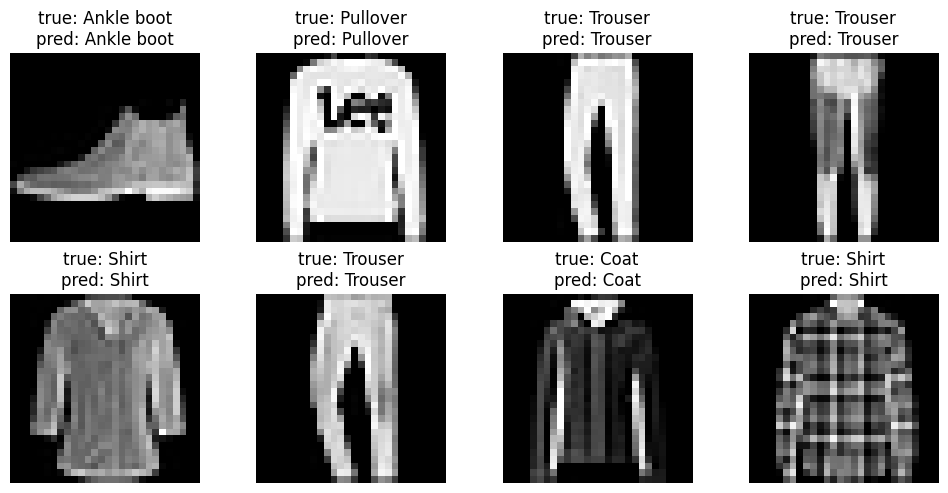

In [21]:
model.eval()
model.freeze()

sample_loader = datamodule.test_dataloader()
images, labels = next(iter(sample_loader))
with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, label, pred in zip(axes.flatten(), images, labels, preds):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"true: {CFG.label_map[label]}\npred: {CFG.label_map[pred]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## TensorBoard

Логи сохраняются в `lightning_logs/`. Для просмотра локально:

```bash
%load_ext tensorboard
%tensorboard --logdir lightning_logs
```


## Итоги и интерпретация

- Сходимость: за первые эпохи train_loss падает, val_loss снижается до ~0.54, val_f1 ~0.79 (по логам). ReduceLROnPlateau + EarlyStopping предотвращают лишние эпохи и переобучение.
- Качество на тесте: test_loss ≈ 0.50, test_f1 ≈ 0.81, test_auroc ≈ 0.98 (torchmetrics). Высокий AUROC показывает уверенное ранжирование; F1 ограничен путаницей похожих классов (T-shirt/top vs shirt и т.п.).
- Архитектура: компактная CNN с BatchNorm и Dropout (Lecture 04/07) стабилизирует обучение и снижает переобучение.
- Оптимизация: AdamW (Lecture 05) + ReduceLROnPlateau (Lecture 08) + EarlyStopping адаптируют шаг и вовремя останавливают обучение.
- Аугментации: лёгкие Rotation/HorizontalFlip (Lecture 12) повышают устойчивость к вариациям позы/зеркальности.
- Воспроизводимость: seed=42, фиксированный split 55k/5k/10k, данные в `data/fashionmnist`, окружение `dl_hw_2`, ноутбук выполняется подряд.
- Возможные улучшения: поднять `max_epochs`, добавить TensorBoard (`pip install tensorboard`) для просмотра кривых, увеличить `num_workers`, попробовать CosineAnnealingLR/OneCycleLR или чуть более глубокую CNN/доп. Dropout.
